Use the Movies.csv file as shared and do the following tasks

Tasks to Solve
1. Compute mean, standard deviation, min, and max of the Rating field.
2. Plot a histogram of the Rating field using Matplotlib.
3. Find the mean rating grouped by Country and plot them as a bar chart.
4. Find the minimum and maximum duration grouped by Year.
5. Calculate average duration of movies yearwise , then plot them using both Matplotlib and Seaborn.
6. Generate box plots for Rating, duration, and ReleaseYear.
7. Use Seaborn’s factorplot (or catplot) to analyze how Rating varies across Genre and Country.

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rich import print as pprint

In [2]:
with open("../../datasets/Movies.csv", encoding="latin-1", newline="") as f:
    reader = csv.reader(f)
    lines = list(reader)

In [3]:
header = lines[0]
rows = np.array(lines[1:])
rating_col = rows[:, header.index("rating")]
print(list(np.unique(rating_col)))

[np.str_(''), np.str_('G'), np.str_('NC-17'), np.str_('NR'), np.str_('PG'), np.str_('PG-13'), np.str_('R'), np.str_('TV-14'), np.str_('TV-G'), np.str_('TV-MA'), np.str_('TV-PG'), np.str_('TV-Y'), np.str_('TV-Y7'), np.str_('TV-Y7-FV'), np.str_('UR')]


In [4]:
rating_to_age = {
    "": 0,
    "G": 0,
    "TV-G": 0,
    "TV-Y": 0,
    "TV-Y7": 7,
    "TV-Y7-FV": 7,
    "PG": 10,
    "TV-PG": 10,
    "PG-13": 13,
    "TV-14": 14,
    "R": 17,
    "NC-17": 18,
    "TV-MA": 17,
    "NR": 0,
    "UR": 0,
}

In [5]:
ages = np.array([rating_to_age.get(r, None) for r in rating_col], dtype=np.float32)

In [6]:
print(np.unique(ages))

[ 0.  7. 10. 13. 14. 17. 18.]


In [7]:
print(f"Mean: {ages.mean()}")
print(f"Std deviation: {ages.std()}")
print(f"Max: {ages.max()}")
print(f"Min: {ages.min()}")

Mean: 13.426351547241211
Std deviation: 4.799947261810303
Max: 18.0
Min: 0.0


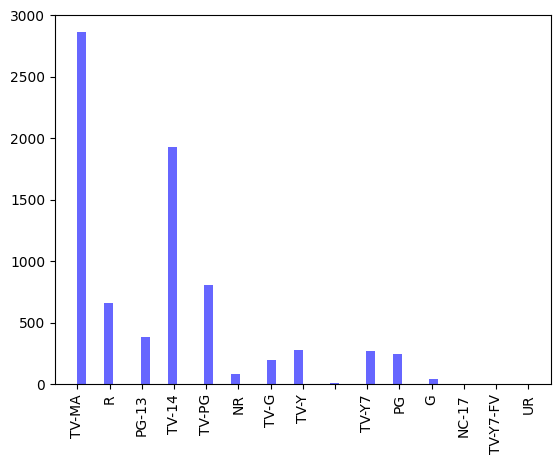

In [8]:
_ = plt.hist(rating_col, 50, facecolor="b", alpha=0.6)
plt.xticks(rotation=90)
plt.show()

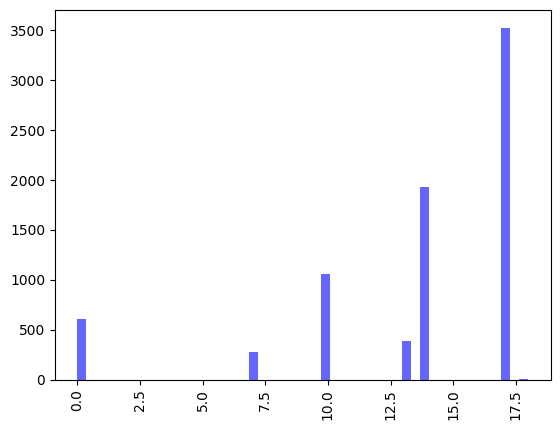

In [9]:
_ = plt.hist(ages, 50, facecolor="b", alpha=0.6)
plt.xticks(rotation=90)
plt.show()

In [10]:
countries = rows[:, header.index("country")]
unique_countries = set()
for country_str in countries:
    for country in country_str.split(","):
        unique_countries.add(country)

country_list = {c: [] for c in unique_countries}

for r in rows:
    countries = r[header.index("country")].split(",")
    rating = rating_to_age.get(r[header.index("rating")], 0)
    for country in countries:
        country_list[country].append(rating)

country_mean = {c: np.mean(ages).item() for c, ages in country_list.items()}
pprint(country_mean)

{
    np.str_(''): 11.315068493150685,
    ' Uruguay': 16.4,
    ' Peru': 15.5,
    ' United Kingdom': 13.157534246575343,
    'Namibia': 10.0,
    ' Slovenia': 17.0,
    'Lebanon': 15.35,
    'New Zealand': 14.866666666666667,
    ' Russia': 13.142857142857142,
    ' Uganda': 0.0,
    ' Syria': 14.0,
    'Greece': 17.0,
    ' Bangladesh': 0.0,
    ' Norway': 15.333333333333334,
    'Puerto Rico': 17.0,
    ' China': 13.245901639344263,
    ' Netherlands': 13.95,
    'Finland': 14.166666666666666,
    'Turkey': 14.49056603773585,
    'Iceland': 16.4,
    ' Sweden': 15.217391304347826,
    ' Taiwan': 11.333333333333334,
    'Poland': 16.615384615384617,
    ' Poland': 16.0,
    'Ireland': 14.153846153846153,
    'Brazil': 14.050632911392405,
    ' Pakistan': 15.5,
    ' Angola': 17.0,
    ' Mongolia': 17.0,
    'Cyprus': 0.0,
    'Mexico': 15.065040650406504,
    ' Switzerland': 13.9,
    ' Croatia': 13.5,
    'Argentina': 14.897058823529411,
    ' Singapore': 13.727272727272727,
    'United States': 13.168227540756156,
    'Mauritius': 17.0,
    'Belgium': 15.571428571428571,
    'Kenya': 15.0,
    'Portugal': 17.0,
    'Croatia': 17.0,
    ' South Korea': 9.833333333333334,
    'Israel': 15.052631578947368,
    ' Lebanon': 14.833333333333334,
    'Italy': 13.915254237288135,
    ' Bulgaria': 15.25,
    'Serbia': 17.0,
    ' Senegal': 15.5,
    'Venezuela': 7.0,
    ' Hungary': 16.4,
    'Malaysia': 11.91304347826087,
    ' United Arab Emirates': 12.6,
    'Russia': 11.45,
    ' Czech Republic': 14.666666666666666,
    ' Mexico': 13.870967741935484,
    'Nigeria': 14.492957746478874,
    ' Australia': 12.277777777777779,
    'Georgia': 12.0,
    ' Morocco': 14.833333333333334,
    ' Iraq': 17.0,
    ' Kazakhstan': 7.0,
    ' Ireland': 11.5,
    ' Cambodia': 12.333333333333334,
    ' Japan': 11.56,
    ' Latvia': 17.0,
    'Denmark': 13.3,
    'Philippines': 13.946666666666667,
    ' Azerbaijan': 14.0,
    ' Botswana': 10.0,
    ' Greece': 11.88888888888889,
    ' Albania': 17.0,
    ' Brazil': 12.11111111111111,
    ' Thailand': 16.0,
    ' Kenya': 17.0,
    ' Soviet Union': 14.0,
    'Uruguay': 11.666666666666666,
    'Ukraine': 15.5,
    ' Germany': 13.738317757009346,
    'India': 13.751046025104603,
    ' Zimbabwe': 8.5,
    ' Jordan': 15.0,
    ' Sri Lanka': 0.0,
    'Colombia': 15.833333333333334,
    ' Turkey': 17.0,
    ' Ecuador': 10.0,
    ' Vatican City': 10.0,
    'Peru': 13.166666666666666,
    'Japan': 13.561181434599156,
    ' Kuwait': 14.0,
    'Somalia': 17.0,
    'Senegal': 17.0,
    ' Luxembourg': 13.818181818181818,
    ' Afghanistan': 17.0,
    ' New Zealand': 11.846153846153847,
    ' Philippines': 15.666666666666666,
    'Taiwan': 14.804878048780488,
    'Austria': 15.75,
    'Czech Republic': 15.8,
    'Jordan': 17.0,
    ' Ukraine': 17.0,
    ' Argentina': 15.285714285714286,
    ' Colombia': 14.0,
    'Slovenia': 14.0,
    'Singapore': 14.535714285714286,
    'China': 13.034883720930232,
    'Chile': 16.238095238095237,
    ' Nepal': 10.0,
    ' Spain': 15.042553191489361,
    'Norway': 15.8,
    ' Slovakia': 17.0,
    'Guatemala': 17.0,
    ' East Germany': 0.0,
    ' Montenegro': 17.0,
    ' Samoa': 14.0,
    'Paraguay': 17.0,
    'Kuwait': 11.5,
    'Belarus': 0.0,
    ' Guatemala': 0.0,
    ' Sudan': 17.0,
    'Australia': 12.027777777777779,
    ' Chile': 15.8,
    ' Malawi': 10.0,
    ' Cuba': 17.0,
    'West Germany': 17.0,
    ' Finland': 11.4,
    ' Serbia': 14.25,
    ' Egypt': 15.8,
    ' Italy': 12.161290322580646,
    ' Bermuda': 10.0,
    ' Austria': 11.333333333333334,
    'Cambodia': 17.0,
    ' Bahamas': 13.0,
    ' Israel': 15.571428571428571,
    ' South Africa': 14.842105263157896,
    ' Belgium': 14.746478873239436,
    ' Algeria': 17.0,
    'Germany': 13.891304347826088,
    'Bulgaria': 17.0,
    ' Iceland': 14.5,
    'Saudi Arabia': 13.5,
    'Jamaica': 17.0,
    'Spain': 15.55952380952381,
    'Zimbabwe': 0.0,
    'South Korea': 13.845360824742269,
    'Romania': 15.7,
    ' Ni

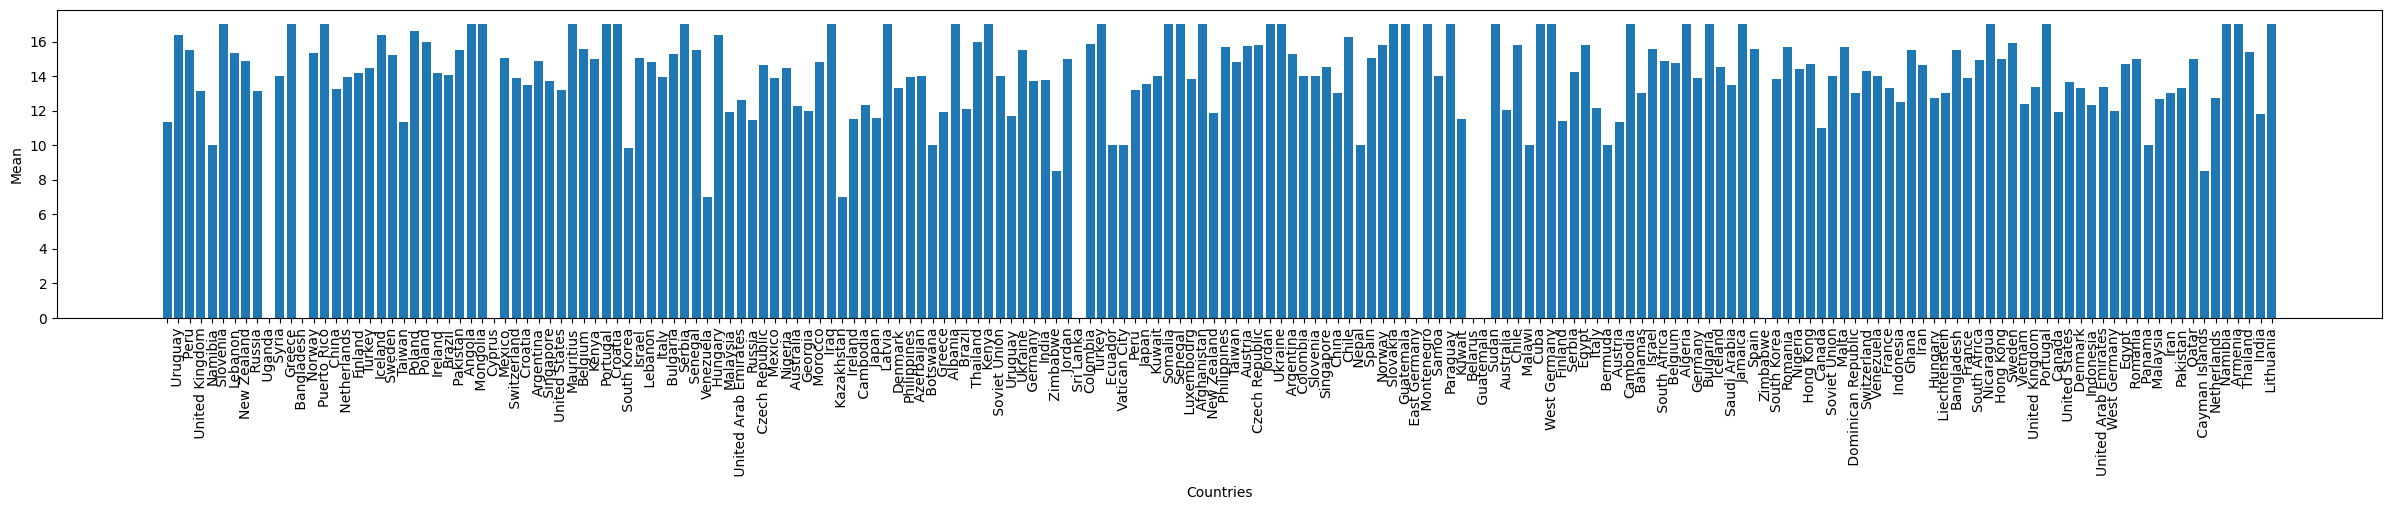

In [11]:
x = country_mean.keys()
y = country_mean.values()
plt.figure(figsize=(30, 4))
plt.bar(x, y)
plt.xticks(rotation=90)
plt.xlabel("Countries")
plt.ylabel("Mean")
plt.show()

In [12]:
duration = rows[:, header.index("duration")]
unique_duration = np.unique(duration)
print(list(unique_duration))

[np.str_('1 Season'), np.str_('10 Seasons'), np.str_('10 min'), np.str_('100 min'), np.str_('101 min'), np.str_('102 min'), np.str_('103 min'), np.str_('104 min'), np.str_('105 min'), np.str_('106 min'), np.str_('107 min'), np.str_('108 min'), np.str_('109 min'), np.str_('11 Seasons'), np.str_('11 min'), np.str_('110 min'), np.str_('111 min'), np.str_('112 min'), np.str_('113 min'), np.str_('114 min'), np.str_('115 min'), np.str_('116 min'), np.str_('117 min'), np.str_('118 min'), np.str_('119 min'), np.str_('12 Seasons'), np.str_('12 min'), np.str_('120 min'), np.str_('121 min'), np.str_('122 min'), np.str_('123 min'), np.str_('124 min'), np.str_('125 min'), np.str_('126 min'), np.str_('127 min'), np.str_('128 min'), np.str_('129 min'), np.str_('13 Seasons'), np.str_('13 min'), np.str_('130 min'), np.str_('131 min'), np.str_('132 min'), np.str_('133 min'), np.str_('134 min'), np.str_('135 min'), np.str_('136 min'), np.str_('137 min'), np.str_('138 min'), np.str_('139 min'), np.str_('1

In [13]:
def dur_to_num(duration):
    if "min" in duration:
        return int(duration.split("min")[0])
    if "Season" in duration:
        return int(duration.split("Season")[0]) * 200

    return 0

In [14]:
years = rows[:, header.index("release_year")]
unique_years = np.unique(years)
year_min_max = {}
for year in unique_years:
    duration = np.array(
        [dur_to_num(r) for r in rows[years == year, header.index("duration")]],
        dtype=np.float32,
    )
    year_min_max[year.item()] = [duration.min().item(), duration.max().item()]

pprint(year_min_max)

{
    '1925': [200.0, 200.0],
    '1942': [18.0, 52.0],
    '1943': [45.0, 82.0],
    '1944': [40.0, 76.0],
    '1945': [32.0, 63.0],
    '1946': [58.0, 200.0],
    '1947': [42.0, 42.0],
    '1954': [116.0, 120.0],
    '1955': [93.0, 111.0],
    '1956': [98.0, 104.0],
    '1958': [73.0, 115.0],
    '1959': [143.0, 143.0],
    '1960': [108.0, 181.0],
    '1962': [153.0, 185.0],
    '1963': [194.0, 800.0],
    '1964': [228.0, 228.0],
    '1965': [103.0, 200.0],
    '1966': [116.0, 116.0],
    '1967': [90.0, 1600.0],
    '1968': [66.0, 600.0],
    '1969': [128.0, 152.0],
    '1970': [66.0, 130.0],
    '1971': [100.0, 181.0],
    '1972': [91.0, 200.0],
    '1973': [81.0, 253.0],
    '1974': [83.0, 800.0],
    '1975': [92.0, 134.0],
    '1976': [98.0, 157.0],
    '1977': [84.0, 2000.0],
    '1978': [25.0, 141.0],
    '1979': [74.0, 237.0],
    '1980': [93.0, 161.0],
    '1981': [85.0, 200.0],
    '1982': [80.0, 233.0],
    '1983': [69.0, 155.0],
    '1984': [86.0, 230.0],
    '1985': [85.0, 200.0],
    '1986': [80.0, 1200.0],
    '1987': [50.0, 172.0],
    '1988': [48.0, 1000.0],
    '1989': [72.0, 200.0],
    '1990': [30.0, 1000.0],
    '1991': [28.0, 200.0],
    '1992': [61.0, 2200.0],
    '1993': [56.0, 1400.0],
    '1994': [49.0, 200.0],
    '1995': [78.0, 400.0],
    '1996': [81.0, 204.0],
    '1997': [87.0, 800.0],
    '1998': [31.0, 1200.0],
    '1999': [75.0, 1400.0],
    '2000': [56.0, 1400.0],
    '2001': [42.0, 400.0],
    '2002': [78.0, 1200.0],
    '2003': [37.0, 2200.0],
    '2004': [46.0, 800.0],
    '2005': [55.0, 1600.0],
    '2006': [45.0, 2000.0],
    '2007': [70.0, 1600.0],
    '2008': [25.0, 600.0],
    '2009': [29.0, 1200.0],
    '2010': [23.0, 1000.0],
    '2011': [24.0, 1800.0],
    '2012': [23.0, 1800.0],
    '2013': [22.0, 1600.0],
    '2014': [3.0, 1400.0],
    '2015': [12.0, 2600.0],
    '2016': [22.0, 1600.0],
    '2017': [11.0, 3000.0],
    '2018': [12.0, 2400.0],
    '2019': [10.0, 3200.0],
    '2020': [5.0, 1800.0],
    '2021': [14.0, 1000.0]
}

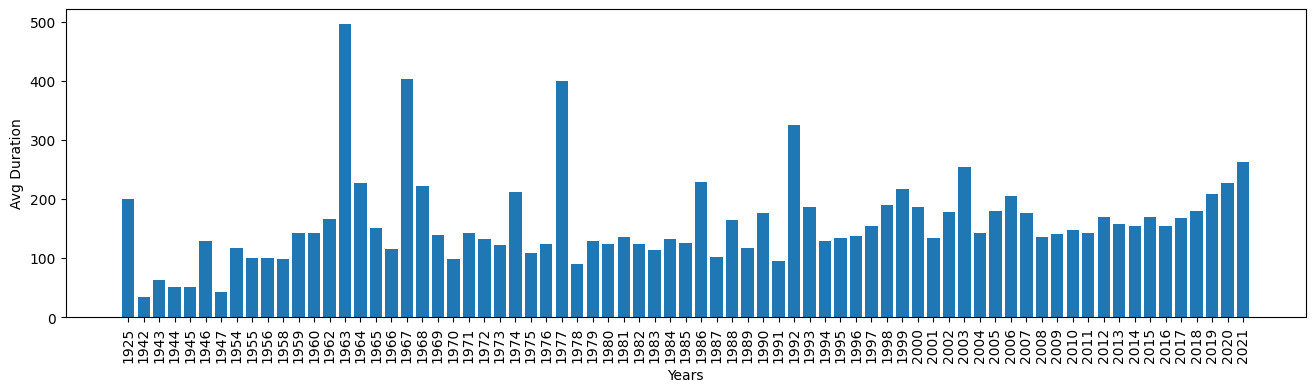

In [15]:
year_avg_dur = {}
for year in unique_years:
    duration = np.array(
        [dur_to_num(r) for r in rows[years == year, header.index("duration")]],
        dtype=np.float32,
    )
    year_avg_dur[year.item()] = duration.mean()


x = year_avg_dur.keys()
y = year_avg_dur.values()
plt.figure(figsize=(16, 4))
plt.bar(x, y)
plt.xticks(rotation=90)
plt.xlabel("Years")
plt.ylabel("Avg Duration")
plt.show()

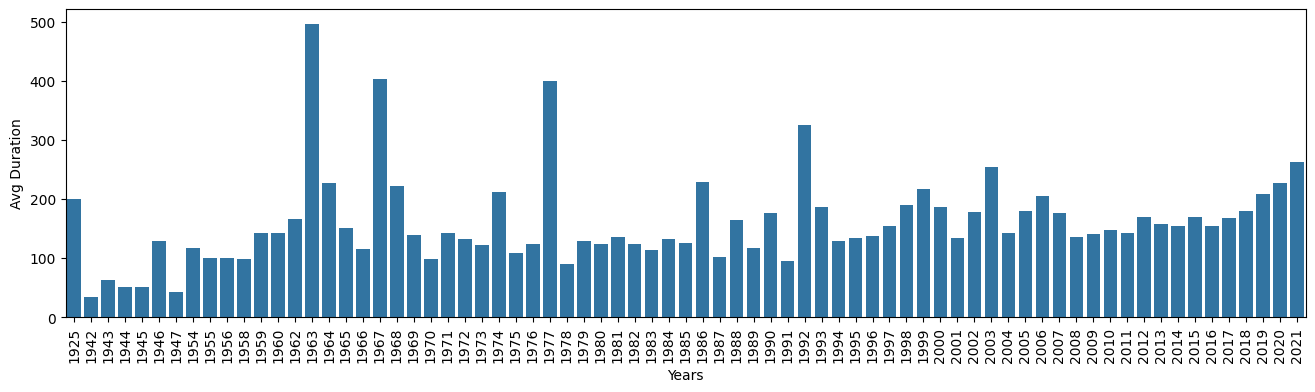

In [16]:
plt.figure(figsize=(16, 4))
sns.barplot(x=x, y=y)
plt.xticks(rotation=90)
plt.xlabel("Years")
plt.ylabel("Avg Duration")
plt.show()

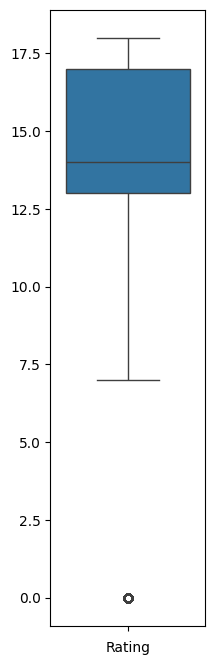

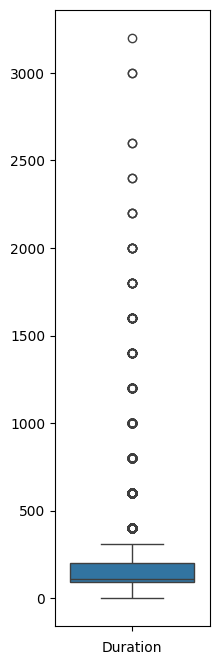

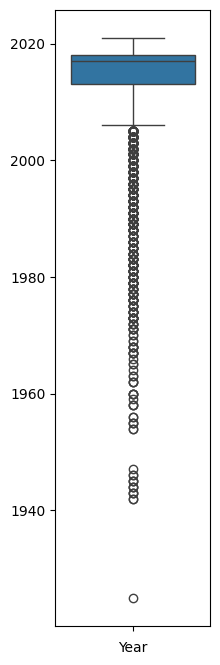

In [17]:
rating_col = list(map(lambda x: rating_to_age[x], rows[:, header.index("rating")]))
duration_col = list(map(dur_to_num, rows[:, header.index("duration")]))
release_year_col = rows[:, header.index("release_year")].astype(np.float32)
metrics = [
    (rating_col, "Rating"),
    (duration_col, "Duration"),
    (release_year_col, "Year"),
]

for metric, name in metrics:
    plt.figure(figsize=(2, 8))
    sns.boxplot(metric)
    plt.xticks(rotation=90)
    plt.xlabel(name)
    plt.show()

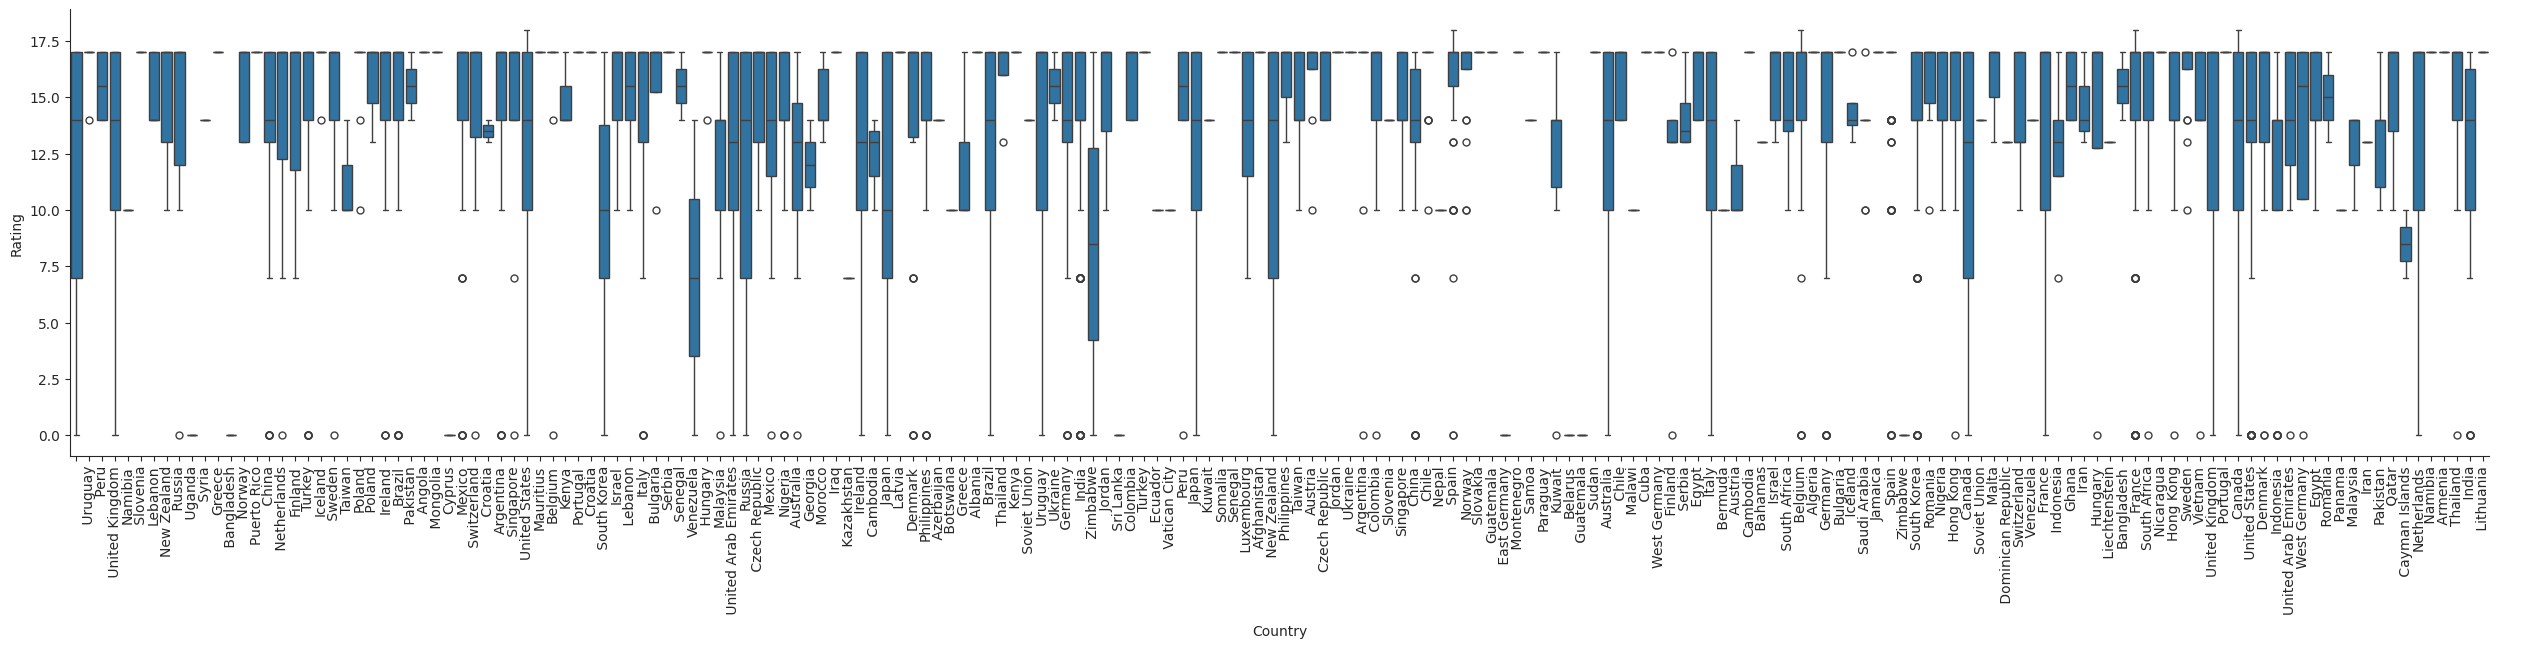

In [18]:
countries = rows[:, header.index("country")]
unique_countries = set()
for country_str in countries:
    for country in country_str.split(","):
        unique_countries.add(country)

country_dict = {c: [] for c in unique_countries}

for r in rows:
    countries = r[header.index("country")].split(",")
    rating = rating_to_age.get(r[header.index("rating")], 0)
    for country in countries:
        country_dict[country].append(rating)

# country_mean = {c: np.mean(ages).item() for c, ages in country_list.items()}
# pprint(country_mean)

country_list = []
rating_list = []
for country, ratings in country_dict.items():
    for rating in ratings:
        country_list.append(country)
        rating_list.append(rating)


with sns.axes_style(style="ticks"):
    g = sns.catplot(x=country_list, y=rating_list, kind="box", height=5, aspect=5)
    plt.xticks(rotation=90)
    g.set_axis_labels("Country", "Rating")
    plt.show()

In [19]:
genres = rows[:, header.index("listed_in")]
unique_genre = set()
for genre_str in genres:
    for genre in genre_str.split(","):
        unique_genre.add(genre)

genre_dict = {c: [] for c in unique_genre}

for r in rows:
    genres = r[header.index("listed_in")].split(",")
    rating = rating_to_age.get(r[header.index("rating")], 0)
    for genre in genres:
        genre_dict[genre].append(rating)

# country_mean = {c: np.mean(ages).item() for c, ages in country_list.items()}
# pprint(country_mean)

genre_list = []
rating_list = []
for genre, ratings in genre_dict.items():
    for rating in ratings:
        genre_list.append(genre)
        rating_list.append(rating)

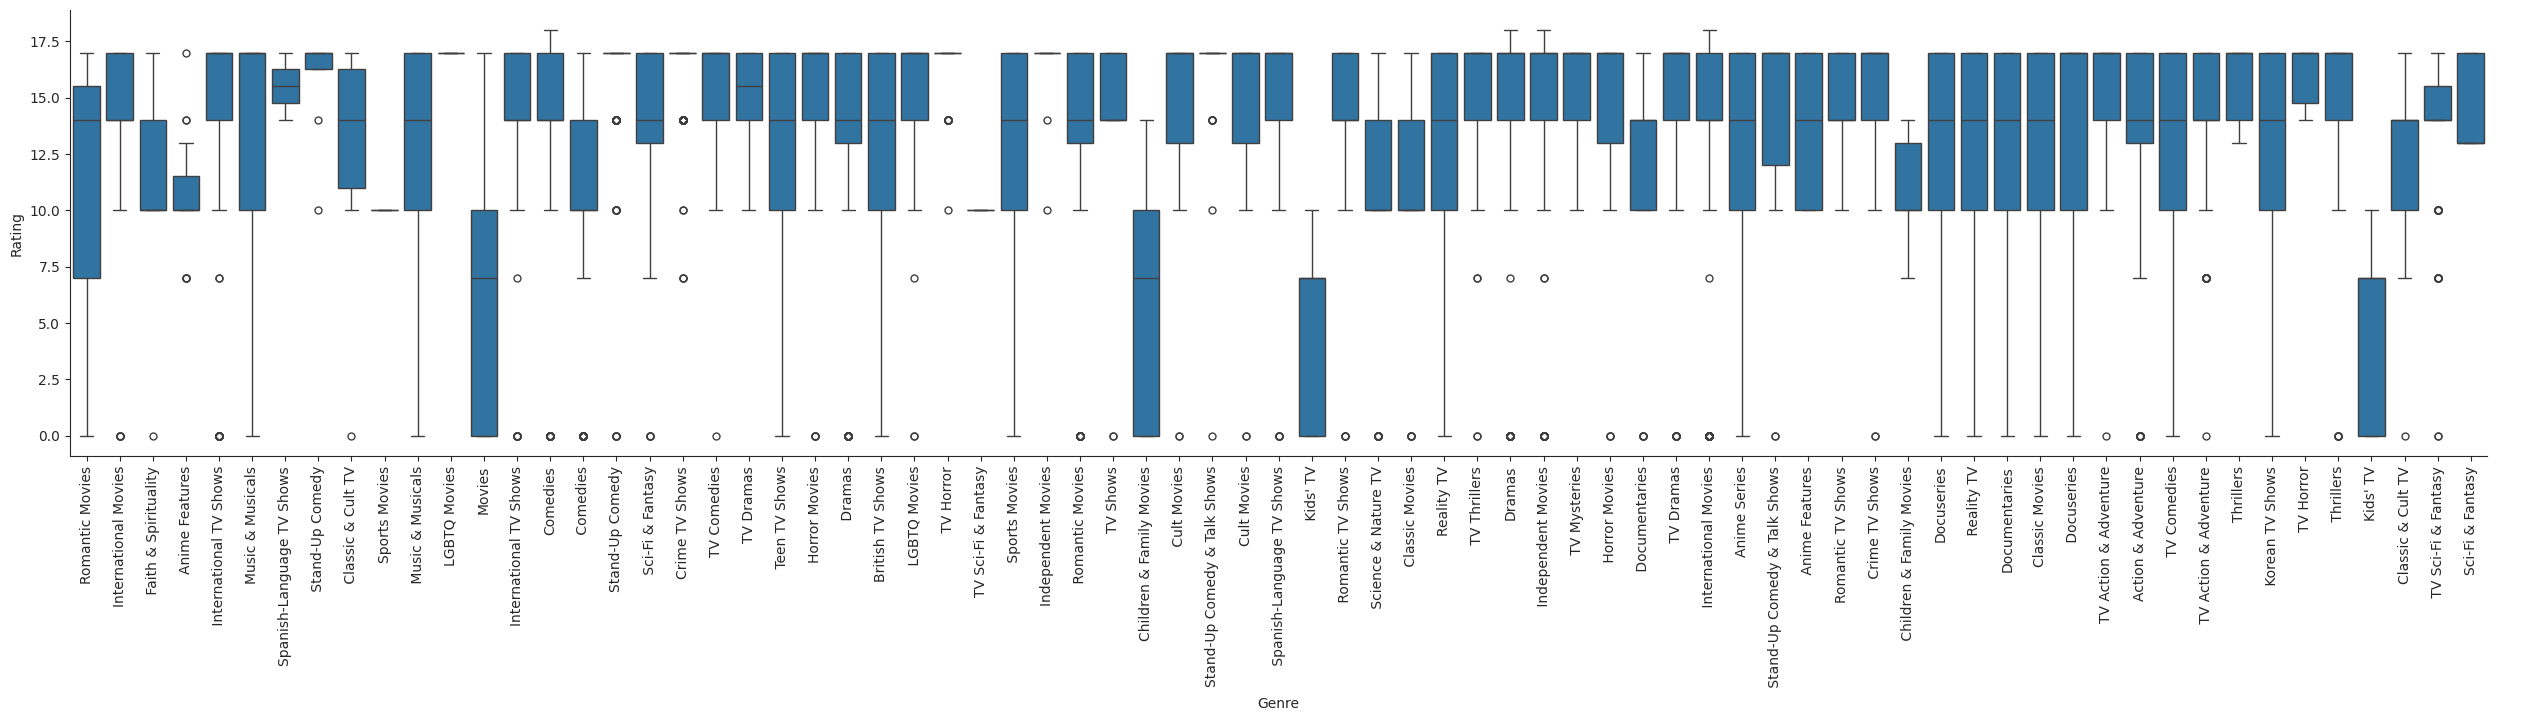

In [20]:
with sns.axes_style(style="ticks"):
    g = sns.catplot(x=genre_list, y=rating_list, kind="box", height=5, aspect=5)
    plt.xticks(rotation=90)
    g.set_axis_labels("Genre", "Rating")
    plt.show()

In [24]:
combined_dict = {(c, g): [] for g in unique_genre for c in unique_countries}

for r in rows:
    genres = r[header.index("listed_in")].split(",")
    countries = r[header.index("country")].split(",")
    rating = rating_to_age.get(r[header.index("rating")], 0)
    for genre in genres:
        for country in countries:
            combined_dict[(country, genre)].append(rating)

# country_mean = {c: np.mean(ages).item() for c, ages in country_list.items()}
# pprint(country_mean)

genre_list = []
country_list = []
rating_list = []
for comb, ratings in combined_dict.items():
    for rating in ratings:
        country_list.append(comb[0])
        genre_list.append(comb[1])
        rating_list.append(rating)

/home/tushya/programs/college/data_analysis/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self._figure.tight_layout(*args, **kwargs)
/home/tushya/programs/college/data_analysis/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


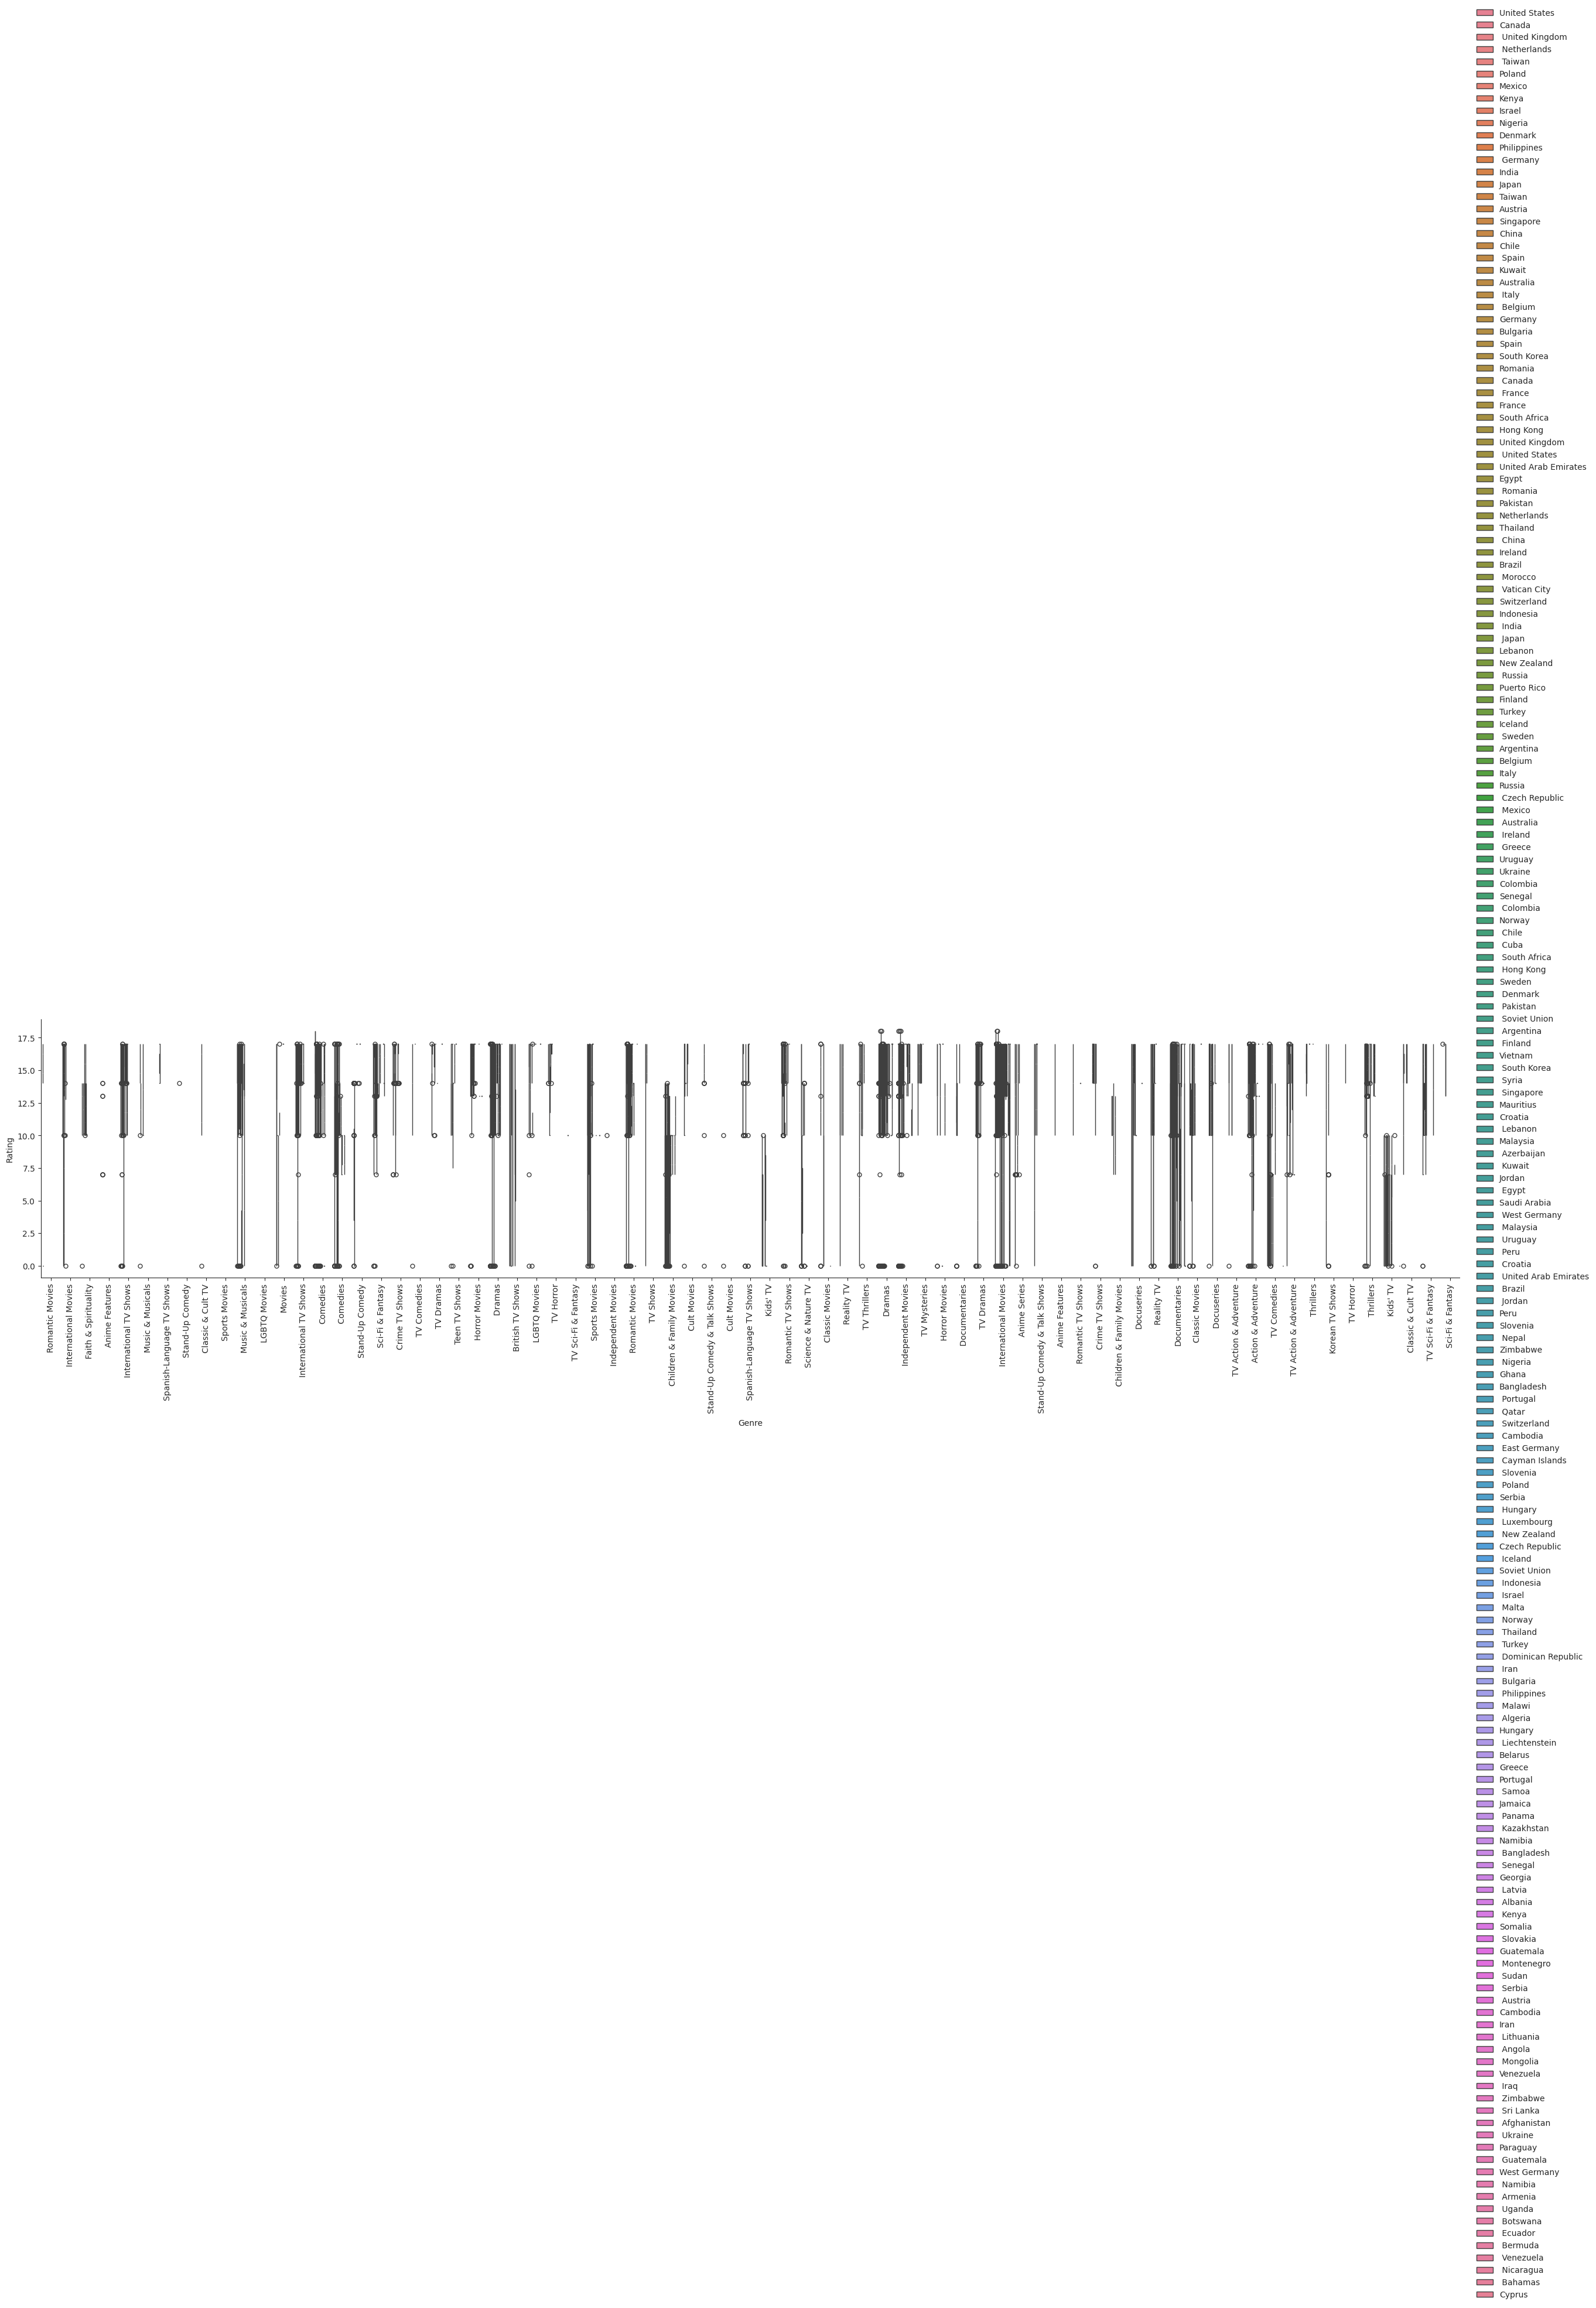

In [ ]:
with sns.axes_style(style="ticks"):
    g = sns.catplot(
        x=genre_list, y=rating_list, hue=country_list, kind="box", height=5, aspect=5
    )
    plt.xticks(rotation=90)
    g.set_axis_labels("Genre", "Rating")
    plt.show()